# 01a — Verify Real Data

**Purpose:** Phân tích đặc trưng thống kê của dataset thực (Amazon Reviews) để hiểu cấu trúc dữ liệu trước khi sinh dữ liệu synthetic.

Notebook này **không chạy benchmark**. Chỉ đọc từ:
- `data/benchmark_real/` — Amazon Reviews đã được tiền xử lý

---

**Các phân tích được thực hiện:**
1. Load & kiểm tra schema
2. Phân phối độ dài văn bản (`text_len`)
3. Phân phối rating
4. Tần suất user_id (Zipf / long-tail)
5. Tần suất product key (`ITEM_COL`: `parent_asin` hoặc `product_id`) — Zipf / long-tail
6. Cardinality các cột
7. Tóm tắt insight để calibrate synthetic

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy import stats
import pyarrow.parquet as pq


# ── Cấu hình đường dẫn ──
PROJECT_ROOT = Path("../..")
REAL_ROOT = PROJECT_ROOT / "data" / "benchmark_real"

# Chọn dataset đại diện để verify/calibrate
DATASET_SIZE = "1M"   # đổi thành "10M" hoặc "50M" nếu muốn kiểm tra size khác
REAL_DIR = REAL_ROOT / DATASET_SIZE

print(f"Real data root : {REAL_ROOT.resolve()}")
print(f"Selected dir   : {REAL_DIR.resolve()}")
print(f"Exists         : {REAL_DIR.exists()}")

if not REAL_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy folder: {REAL_DIR}")

Real data root : D:\Polar vs Dask\data\benchmark_real
Selected dir   : D:\Polar vs Dask\data\benchmark_real\1M
Exists         : True


In [2]:
# Liệt kê file trong dataset size đã chọn
files = sorted([p for p in REAL_DIR.rglob("*") if p.is_file()])

print(f"Selected dataset: {DATASET_SIZE}")
print(f"Found {len(files)} file(s):\n")

for f in files:
    size_mb = f.stat().st_size / 1e6
    rel_path = f.relative_to(REAL_DIR)
    print(f"  {str(rel_path):<60} {size_mb:>8.1f} MB")

Selected dataset: 1M
Found 2 file(s):

  part-000.parquet                                                134.5 MB
  part-001.parquet                                                 38.3 MB


Folder `1M` hiện gồm 2 parquet parts. Vì dataset được chia thành nhiều part-file, các bước phân tích chính cần load hoặc tính metadata trên **toàn bộ parts**, không chỉ `part-000.parquet`.

In [3]:
# Load data từ dataset size đã chọn
parquet_files = sorted(REAL_DIR.rglob("*.parquet"))
jsonl_files   = sorted(REAL_DIR.rglob("*.jsonl"))

if parquet_files:
    df = pd.concat(
        [pd.read_parquet(p) for p in parquet_files],
        ignore_index=True
    )
    print(f"Loaded {len(parquet_files)} parquet file(s) from {DATASET_SIZE}")

elif jsonl_files:
    df = pd.concat(
        [pd.read_json(p, lines=True) for p in jsonl_files],
        ignore_index=True
    )
    print(f"Loaded {len(jsonl_files)} jsonl file(s) from {DATASET_SIZE}")

else:
    raise FileNotFoundError(f"Không tìm thấy .parquet hoặc .jsonl trong {REAL_DIR}")

print(f"\nShape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Loaded 2 parquet file(s) from 1M

Shape  : (1000000, 10)
Memory : 636.8 MB


,review_id,user_id,product_id,parent_asin,rating,review_title,review_text,review_time,helpful_vote,verified_purchase
0,R5071732930,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B096S6LZV4,B09NSZ5QMF,3,Arrived Damaged : liquid in hub locker!,"Unfortunately Amazon in their wisdom (cough, c...",2023-03-04,0,True
1,R6199037955,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B09KMDBDCN,B08NGL3X17,3,Useless under 40 degrees.,Useless under 40 degrees unless you’re just ru...,2023-02-22,0,False
2,R7070878004,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B096N5WK8Q,B07RGM3DYC,4,"Not waterproof, but a very comfy shoe.",I purchased these bc they are supposed to be w...,2023-02-04,11,True


Dữ liệu `1M` đã được load đủ từ 2 parquet files, kết quả đúng kỳ vọng là `1,000,000` rows và 10 columns. Đây là sample đại diện dùng để calibrate synthetic parameters; không nên load `10M` hoặc `50M` vào pandas trừ khi thật sự cần và máy đủ RAM.

In [4]:
# Kiểm tra schema và dtypes
print("Column dtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Column dtypes:
review_id                    object
user_id                      object
product_id                   object
parent_asin                  object
rating                         int8
review_title                 object
review_text                  object
review_time          datetime64[ns]
helpful_vote                  int32
verified_purchase              bool
dtype: object

Null counts:
review_id            0
user_id              0
product_id           0
parent_asin          0
rating               0
review_title         0
review_text          0
review_time          0
helpful_vote         0
verified_purchase    0
dtype: int64


In [5]:
TEXT_COL   = "review_text"
RATING_COL = "rating"
USER_COL   = "user_id"

# Chọn 1 trong 2 tùy mục tiêu benchmark:
ITEM_COL = "parent_asin"   # khuyên dùng nếu muốn group/join theo product cha
# ITEM_COL = "product_id"  # dùng nếu muốn phân biệt từng variant/SKU

In [6]:
def quick_check_size(size):
    d = REAL_ROOT / size
    parquet_files = sorted(d.rglob("*.parquet"))
    jsonl_files   = sorted(d.rglob("*.jsonl"))

    print(f"\n=== {size} ===")

    if parquet_files:
        total_rows = 0
        total_size_mb = 0

        for p in parquet_files:
            pf = pq.ParquetFile(p)
            total_rows += pf.metadata.num_rows
            total_size_mb += p.stat().st_size / 1e6

        sample = pd.read_parquet(parquet_files[0])

        print(f"Files        : {len(parquet_files)} parquet file(s)")
        print(f"Total rows   : {total_rows:,}")
        print(f"Total size   : {total_size_mb:.1f} MB")
        print(f"Sample source: {parquet_files[0].relative_to(d)}")
        print(f"Sample shape : {sample.shape}")
        print("Columns      :", list(sample.columns))
        print(sample.dtypes)

    elif jsonl_files:
        sample = pd.read_json(jsonl_files[0], lines=True, nrows=100_000)

        print(f"Files        : {len(jsonl_files)} jsonl file(s)")
        print(f"Sample source: {jsonl_files[0].relative_to(d)}")
        print(f"Sample shape : {sample.shape}")
        print("Columns      :", list(sample.columns))
        print(sample.dtypes)

    else:
        print(f"{size}: no data files found")

for size in ["1M", "10M", "50M"]:
    quick_check_size(size)


=== 1M ===
Files        : 2 parquet file(s)
Total rows   : 1,000,000
Total size   : 172.8 MB
Sample source: part-000.parquet
Sample shape : (759518, 10)
Columns      : ['review_id', 'user_id', 'product_id', 'parent_asin', 'rating', 'review_title', 'review_text', 'review_time', 'helpful_vote', 'verified_purchase']
review_id                    object
user_id                      object
product_id                   object
parent_asin                  object
rating                         int8
review_title                 object
review_text                  object
review_time          datetime64[ns]
helpful_vote                  int32
verified_purchase              bool
dtype: object

=== 10M ===
Files        : 14 parquet file(s)
Total rows   : 10,000,000
Total size   : 1545.3 MB
Sample source: part-000.parquet
Sample shape : (759518, 10)
Columns      : ['review_id', 'user_id', 'product_id', 'parent_asin', 'rating', 'review_title', 'review_text', 'review_time', 'helpful_vote', 'verified_p

Sanity check xác nhận 3 benchmark sizes có đúng số dòng mục tiêu: `1M`, `10M`, `50M`, và cùng schema. Vì mục tiêu của notebook là calibrate đặc trưng thống kê, chạy phân tích sâu trên `1M` là đủ; `10M` và `50M` chỉ cần kiểm tra metadata/schema để tránh tốn RAM.

## 2. Text Length Distribution

**Câu hỏi:** Phân phối độ dài văn bản có dạng log-normal không?

Đây là thông số quan trọng nhất để calibrate synthetic generator vì:
- Text length quyết định kích thước bộ nhớ thực tế (GB vs rows)
- Distribution cần được giữ cố định khi scale từ 1M → 50M rows

In [7]:
# Tính text_len nếu chưa có sẵn
if "text_len" not in df.columns:
    df["text_len"] = df[TEXT_COL].fillna("").astype(str).str.len()

text_len = df["text_len"].dropna()

# Thống kê cơ bản
stats_summary = {
    "count"   : len(text_len),
    "mean"    : text_len.mean(),
    "median"  : text_len.median(),
    "std"     : text_len.std(),
    "p50"     : text_len.quantile(0.50),
    "p90"     : text_len.quantile(0.90),
    "p99"     : text_len.quantile(0.99),
    "max"     : text_len.max(),
    "skewness": text_len.skew(),
    "kurtosis": text_len.kurtosis(),
}

print("=== Text Length Statistics ===")
for k, v in stats_summary.items():
    print(f"  {k:<12}: {v:>12.2f}")

=== Text Length Statistics ===
  count       :   1000000.00
  mean        :       204.00
  median      :       122.00
  std         :       261.69
  p50         :       122.00
  p90         :       472.00
  p99         :      1234.00
  max         :     13958.00
  skewness    :         4.71
  kurtosis    :        55.14


## Text Length Statistics

Phân phối độ dài `review_text` cho thấy dữ liệu có xu hướng **lệch phải mạnh** và mang đặc điểm **long-tail** rõ rệt. Median của độ dài review chỉ là **122 ký tự**, thấp hơn đáng kể so với mean là **204 ký tự**, cho thấy phần lớn review tương đối ngắn, trong khi một số review dài kéo giá trị trung bình lên.

Các percentile cũng củng cố nhận định này: **90% review có độ dài không quá 472 ký tự** và **99% review không quá 1,234 ký tự**. Tuy nhiên, review dài nhất lên tới **13,958 ký tự**, lớn hơn rất nhiều so với phần lớn dữ liệu. Điều này cho thấy tồn tại một nhóm nhỏ review cực dài trong tập dữ liệu.

Giá trị **skewness = 4.71** xác nhận phân phối bị lệch phải mạnh, còn **kurtosis = 55.14** cho thấy phân phối có đuôi nặng và nhiều giá trị cực trị. Vì vậy, độ dài review không phù hợp với phân phối normal hoặc uniform. Khi hiệu chỉnh synthetic data, nên sử dụng một phân phối có khả năng mô phỏng long-tail, chẳng hạn như **log-normal distribution**.

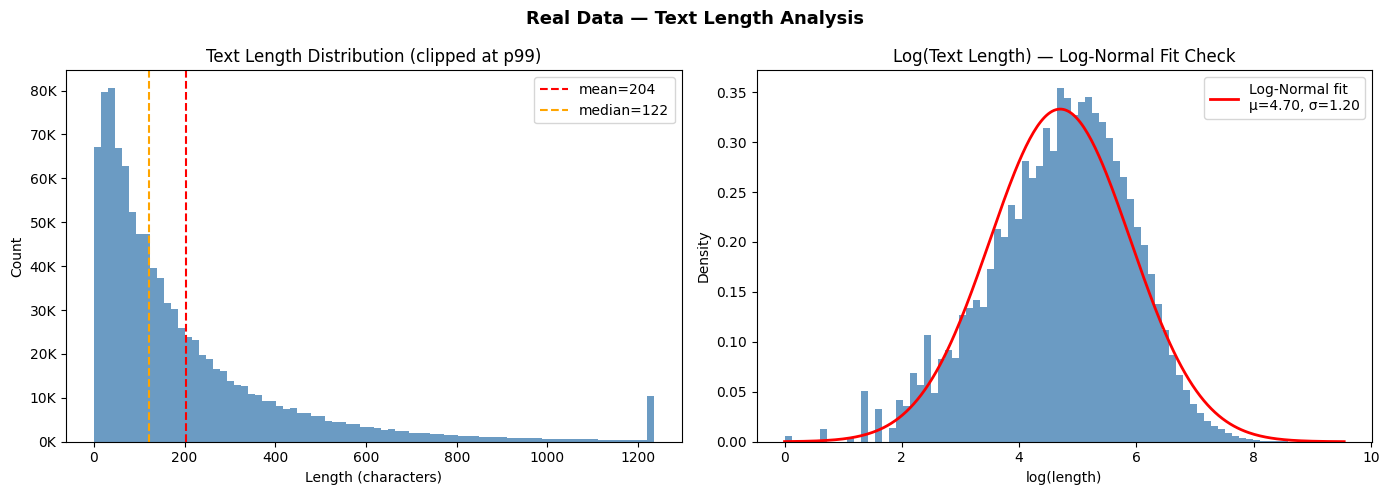


Log-Normal params (for synthetic generator):
  mu    = 4.7013
  sigma = 1.1979


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram (raw) ──
ax = axes[0]
ax.hist(text_len.clip(upper=text_len.quantile(0.99)), bins=80, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(text_len.mean(),   color="red",    linestyle="--", label=f"mean={text_len.mean():.0f}")
ax.axvline(text_len.median(), color="orange", linestyle="--", label=f"median={text_len.median():.0f}")
ax.set_title("Text Length Distribution (clipped at p99)")
ax.set_xlabel("Length (characters)")
ax.set_ylabel("Count")
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# ── Log-scale histogram (kiểm tra log-normal fit) ──
ax2 = axes[1]
log_len = np.log(text_len[text_len > 0])
ax2.hist(log_len, bins=80, color="steelblue", alpha=0.8, edgecolor="none", density=True)

# Fit normal distribution trên log scale
mu, sigma = log_len.mean(), log_len.std()
x = np.linspace(log_len.min(), log_len.max(), 300)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), color="red", linewidth=2,
         label=f"Log-Normal fit\nμ={mu:.2f}, σ={sigma:.2f}")
ax2.set_title("Log(Text Length) — Log-Normal Fit Check")
ax2.set_xlabel("log(length)")
ax2.set_ylabel("Density")
ax2.legend()

plt.suptitle("Real Data — Text Length Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "plots" / "01a_text_len_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLog-Normal params (for synthetic generator):")
print(f"  mu    = {mu:.4f}")
print(f"  sigma = {sigma:.4f}")

## Text Length Distribution

Biểu đồ phân phối độ dài `review_text` cho thấy phần lớn review có độ dài ngắn, tập trung chủ yếu dưới vài trăm ký tự. Đường median nằm tại **122 ký tự**, thấp hơn rõ rệt so với mean **204 ký tự**, cho thấy phân phối bị lệch phải bởi một nhóm nhỏ review dài.

Khi clipping tại p99, phân phối vẫn thể hiện rõ dạng **long-tail**: số lượng review giảm dần khi độ dài tăng, nhưng vẫn tồn tại một phần đuôi kéo dài tới vùng trên 1,000 ký tự. Điều này phù hợp với thống kê trước đó, trong đó p99 đạt **1,234 ký tự** và max lên tới **13,958 ký tự**.

## Log-Normal Fit Check

Biểu đồ log-transform của độ dài text cho thấy phân phối sau khi lấy log có dạng gần giống phân phối chuẩn. Đường fit log-normal bám tương đối tốt vào histogram, đặc biệt ở vùng trung tâm của phân phối.

Kết quả fit cho synthetic generator là:

```text
mu    = 4.7013
sigma = 1.1979
```

Điều này cho thấy log-normal distribution là lựa chọn hợp lý để mô phỏng độ dài review trong synthetic data. Tuy nhiên, phần đuôi và một số giá trị cực trị vẫn cần được kiểm soát, ví dụ bằng clipping hoặc giới hạn max length, để tránh sinh ra các review quá dài không thực tế.

## Key Insight

Độ dài review trong real data không phù hợp với phân phối normal hoặc uniform. Dữ liệu có cấu trúc “nhiều review ngắn, một số ít review rất dài”, nên synthetic data nên sử dụng log-normal distribution với tham số đã fit từ real data.

## 3. Rating Distribution

**Câu hỏi:** Rating phân phối thế nào? Có skewed về phía cao không?

Rating là cột categorical với cardinality thấp (1–5). Cần ghi lại empirical distribution để synthetic generator tái tạo chính xác.

In [9]:
rating_counts = df[RATING_COL].value_counts().sort_index()
rating_probs  = rating_counts / rating_counts.sum()

print("=== Rating Distribution ===")
for r, p in rating_probs.items():
    bar = "█" * int(p * 40)
    print(f"  {r}: {bar:<40} {p:.3%}")

print(f"\nEmpirical probs (for synthetic generator):")
print(dict(rating_probs.round(4)))

=== Rating Distribution ===
  1: ██                                       5.788%
  2: ██                                       5.041%
  3: ███                                      9.093%
  4: ██████                                   16.291%
  5: █████████████████████████                63.787%

Empirical probs (for synthetic generator):
{1: 0.0579, 2: 0.0504, 3: 0.0909, 4: 0.1629, 5: 0.6379}


## Rating Distribution

Phân phối rating cho thấy dữ liệu bị lệch rõ rệt về phía rating cao. Rating **5 sao** chiếm tỷ lệ lớn nhất, khoảng **63.8%** tổng số review, trong khi rating **4 sao** chiếm khoảng **16.3%**. Như vậy, riêng nhóm rating 4–5 sao đã chiếm hơn **80%** dữ liệu.

Ở chiều ngược lại, các rating thấp xuất hiện ít hơn nhiều: rating **1 sao** chiếm khoảng **5.8%**, rating **2 sao** khoảng **5.0%**, và rating **3 sao** khoảng **9.1%**. Điều này cho thấy dữ liệu review có xu hướng tích cực, với phần lớn người dùng để lại đánh giá cao.

Vì `rating` là biến categorical với cardinality thấp từ 1 đến 5, synthetic generator không nên sinh rating bằng phân phối uniform. Thay vào đó, nên sử dụng empirical probabilities quan sát được từ dữ liệu thật:

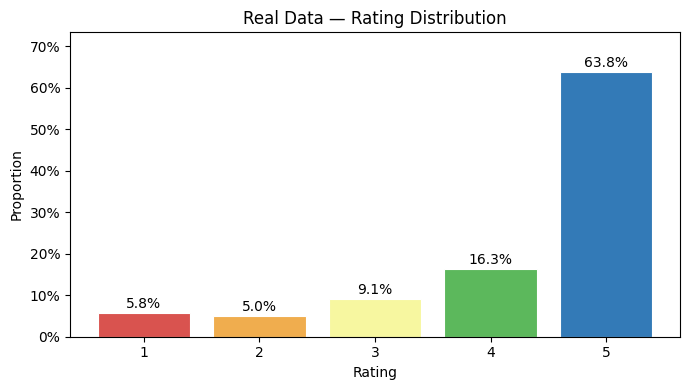

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d9534f", "#f0ad4e", "#f7f7a0", "#5cb85c", "#337ab7"]
bars = ax.bar(rating_counts.index.astype(str), rating_probs.values, color=colors, edgecolor="white", linewidth=0.8)

for bar, p in zip(bars, rating_probs.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{p:.1%}", ha="center", va="bottom", fontsize=10)

ax.set_title("Real Data — Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_ylim(0, rating_probs.max() * 1.15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "plots" / "01a_rating_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## Rating Distribution

Biểu đồ rating distribution cho thấy dữ liệu review bị **lệch mạnh về phía rating cao**. Rating **5 sao** chiếm tỷ lệ áp đảo với khoảng **63.8%** tổng số review, trong khi rating **4 sao** chiếm khoảng **16.3%**. Như vậy, nhóm rating tích cực từ 4–5 sao chiếm hơn **80%** dữ liệu.

Các rating thấp xuất hiện ít hơn đáng kể. Rating **1 sao** chiếm khoảng **5.8%**, rating **2 sao** khoảng **5.0%**, và rating **3 sao** khoảng **9.1%**. Điều này cho thấy tập dữ liệu có xu hướng thiên về các đánh giá tích cực, thay vì phân bố đều giữa các mức rating.

Vì `rating` là biến categorical với cardinality thấp từ 1 đến 5, synthetic generator nên tái tạo rating dựa trên **empirical distribution** từ dữ liệu thật, thay vì sinh ngẫu nhiên theo uniform distribution. Cách này giúp synthetic data giữ lại đặc điểm mất cân bằng tự nhiên của rating, đặc biệt là việc rating 5 sao chiếm ưu thế.

## 4. User ID Frequency — Zipf Behavior

**Câu hỏi:** Tần suất user có tuân theo phân phối Zipf (power-law) không?

Đây là yếu tố quan trọng cho benchmark join và groupby:
- Zipf distribution → skewed access pattern → hot-key bottleneck
- Cần capture đúng `alpha` parameter để synthetic data có cùng skew

In [11]:
user_freq = df[USER_COL].value_counts()

print("=== User ID Frequency Stats ===")
print(f"  Unique users     : {len(user_freq):,}")
print(f"  Total reviews    : {user_freq.sum():,}")
print(f"  Max reviews/user : {user_freq.max():,}")
print(f"  p99 reviews/user : {user_freq.quantile(0.99):.0f}")
print(f"  Median           : {user_freq.median():.0f}")

# Tỉ lệ user chỉ review 1 lần
single_review_pct = (user_freq == 1).sum() / len(user_freq)
print(f"  Single-review %  : {single_review_pct:.1%}")

=== User ID Frequency Stats ===
  Unique users     : 119,926
  Total reviews    : 1,000,000
  Max reviews/user : 4,294
  p99 reviews/user : 60
  Median           : 4
  Single-review %  : 21.8%


## User ID Frequency — Zipf Behavior

Phân tích tần suất `user_id` cho thấy dữ liệu có mức độ skew rõ rệt theo hướng **long-tail / Zipf-like behavior**. Trong 1,000,000 review, chỉ có **119,926 unique users**, nghĩa là trung bình mỗi user xuất hiện nhiều hơn một lần trong dữ liệu.

Median số review trên mỗi user là **4**, cho thấy một user điển hình chỉ viết số lượng review tương đối nhỏ. Tuy nhiên, giá trị **p99 = 60** và max lên tới **4,294 reviews/user** cho thấy tồn tại một nhóm nhỏ user có số lượng review rất lớn. Đây là dấu hiệu điển hình của phân phối lệch, trong đó phần lớn user có tần suất thấp, còn một số ít user hoạt động rất nhiều.

Tỷ lệ **single-review users = 21.8%** cho thấy hơn một phần năm số user chỉ xuất hiện đúng một lần. Điều này củng cố đặc điểm long-tail: nhiều user có activity thấp, trong khi một nhóm nhỏ user tạo ra tỷ lệ review lớn hơn đáng kể.

Đặc điểm này quan trọng cho benchmark `groupby` và `join`, vì các user có tần suất rất cao có thể tạo ra **hot-key bottleneck**. Khi sinh synthetic data, cần giữ lại mức độ skew này thay vì phân phối user đều nhau. Synthetic generator nên sử dụng phân phối kiểu **Zipf / power-law** và calibrate tham số `alpha` dựa trên tần suất user thực tế.

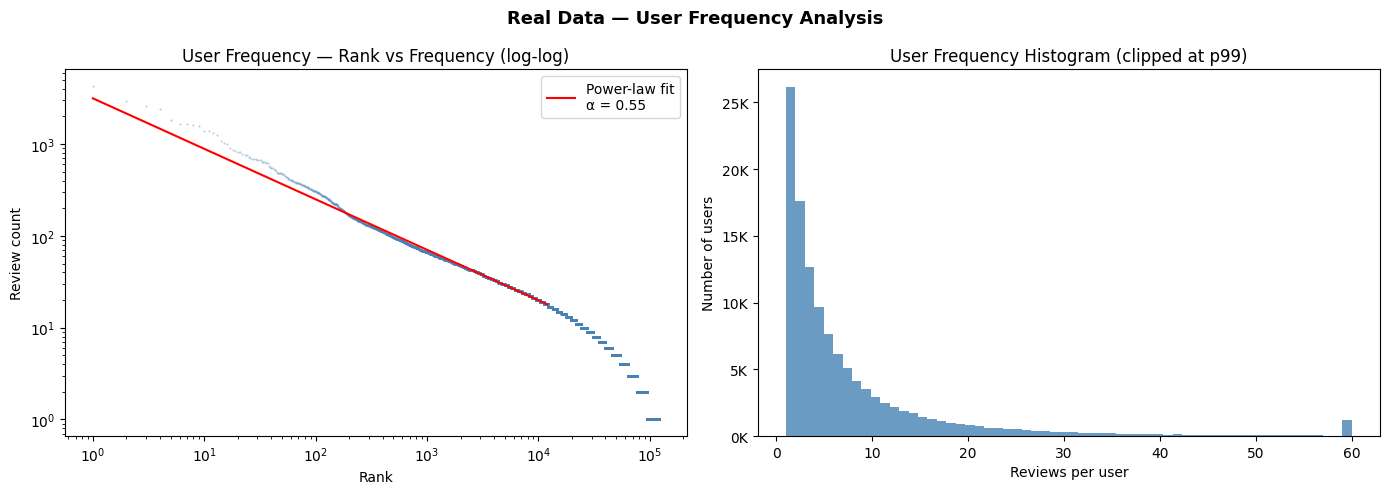


Zipf alpha estimate (for synthetic generator): 0.5500
Lưu ý: alpha là slope rank-frequency ước lượng trên top 10%; dùng nhất quán với synthetic generator.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Rank-Frequency plot (log-log) ── kiểm tra Zipf
ax = axes[0]
ranks = np.arange(1, len(user_freq) + 1)
freqs = user_freq.values

ax.loglog(ranks, freqs, ".", markersize=1, alpha=0.4, color="steelblue")

# Fit power-law trên top 10%
top_n   = max(100, len(ranks) // 10)
log_r   = np.log(ranks[:top_n])
log_f   = np.log(freqs[:top_n])
slope, intercept = np.polyfit(log_r, log_f, 1)
fit_line = np.exp(intercept) * ranks[:top_n] ** slope
ax.loglog(ranks[:top_n], fit_line, color="red", linewidth=1.5,
          label=f"Power-law fit\nα = {-slope:.2f}")

ax.set_title("User Frequency — Rank vs Frequency (log-log)")
ax.set_xlabel("Rank")
ax.set_ylabel("Review count")
ax.legend()

# ── Histogram của frequency ──
ax2 = axes[1]
ax2.hist(user_freq.clip(upper=user_freq.quantile(0.99)), bins=60,
         color="steelblue", alpha=0.8, edgecolor="none")
ax2.set_title("User Frequency Histogram (clipped at p99)")
ax2.set_xlabel("Reviews per user")
ax2.set_ylabel("Number of users")
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("Real Data — User Frequency Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "plots" / "01a_user_freq.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nZipf alpha estimate (for synthetic generator): {-slope:.4f}")
print("Lưu ý: alpha là slope rank-frequency ước lượng trên top 10%; dùng nhất quán với synthetic generator.")

## User ID Frequency — Zipf Behavior

Phân tích tần suất `user_id` cho thấy dữ liệu có đặc điểm **Zipf-like / power-law** khá rõ. Trên biểu đồ rank-frequency dạng log-log, tần suất review giảm dần theo rank và tạo thành xu hướng gần tuyến tính ở phần đầu của phân phối. Điều này cho thấy một nhóm nhỏ user xuất hiện rất nhiều lần, trong khi phần lớn user chỉ có số lượng review thấp.

Trong 1,000,000 review, có **119,926 unique users**. Median số review trên mỗi user là **4**, nhưng p99 đạt **60 reviews/user** và user có tần suất cao nhất đạt tới **4,294 reviews**. Ngoài ra, **21.8% user** chỉ xuất hiện đúng một lần. Các con số này xác nhận dữ liệu có mức độ skew cao và tồn tại long-tail rõ rệt trong hành vi review của user.

Histogram tần suất user cũng cho thấy phần lớn user tập trung ở vùng số review thấp, sau đó giảm nhanh khi số review tăng. Tuy nhiên, vẫn tồn tại một nhóm nhỏ user có tần suất rất cao, có thể tạo ra **hot-key bottleneck** trong các workload như `groupby` hoặc `join`.

Tham số Zipf ước lượng cho synthetic generator là:

```text
alpha = 0.5500
```

Giá trị này được ước lượng từ slope của rank-frequency plot trên top 10% user và nên được dùng nhất quán khi sinh synthetic data. Việc giữ lại phân phối user dạng Zipf/power-law là cần thiết để synthetic data phản ánh đúng mức độ skew của real data.

## 5. Product Key Frequency — Zipf Behavior

**Câu hỏi:** Product key có phân phối tương tự user không?

Product-key frequency quan trọng cho benchmark join — số lượng unique key ảnh hưởng đến hash table size và join cost.

In [13]:
item_freq = df[ITEM_COL].value_counts()

print(f"=== {ITEM_COL} Frequency Stats ===")
print(f"  Unique items      : {len(item_freq):,}")
print(f"  Max reviews/item  : {item_freq.max():,}")
print(f"  p99 reviews/item  : {item_freq.quantile(0.99):.0f}")
print(f"  Median            : {item_freq.median():.0f}")

# So sánh ratio user vs item cardinality
print(f"\n  user cardinality  : {len(user_freq):,}")
print(f"  item cardinality  : {len(item_freq):,}")
print(f"  user/item ratio   : {len(user_freq)/len(item_freq):.1f}x")

=== parent_asin Frequency Stats ===
  Unique items      : 476,112
  Max reviews/item  : 4,772
  p99 reviews/item  : 18
  Median            : 1

  user cardinality  : 119,926
  item cardinality  : 476,112
  user/item ratio   : 0.3x


## Product Key Frequency — Zipf Behavior

Phân tích tần suất `parent_asin` cho thấy product key cũng có đặc điểm **skew / long-tail**, nhưng khác với user frequency ở mức cardinality. Trong 1,000,000 review, có tới **476,112 unique items**, cao hơn nhiều so với số lượng unique users là **119,926**. Tỷ lệ user/item chỉ khoảng **0.3x**, cho thấy không gian product key rộng hơn đáng kể so với user key.

Median số review trên mỗi item là **1**, nghĩa là phần lớn sản phẩm chỉ xuất hiện một lần trong tập dữ liệu. Tuy nhiên, p99 đạt **18 reviews/item** và item có tần suất cao nhất đạt tới **4,772 reviews**. Điều này cho thấy tuy đa số product key rất thưa, vẫn tồn tại một nhóm nhỏ sản phẩm phổ biến có số lượng review rất lớn.

Đặc điểm này quan trọng cho benchmark `join` và `groupby`. Cardinality cao của `parent_asin` làm cho dữ liệu phân tán trên rất nhiều key, trong khi các item phổ biến có thể tạo ra hot keys. Vì vậy, synthetic data cần giữ lại cả hai yếu tố: số lượng unique product key lớn và phân phối tần suất dạng long-tail, thay vì sinh product key theo phân phối đều.

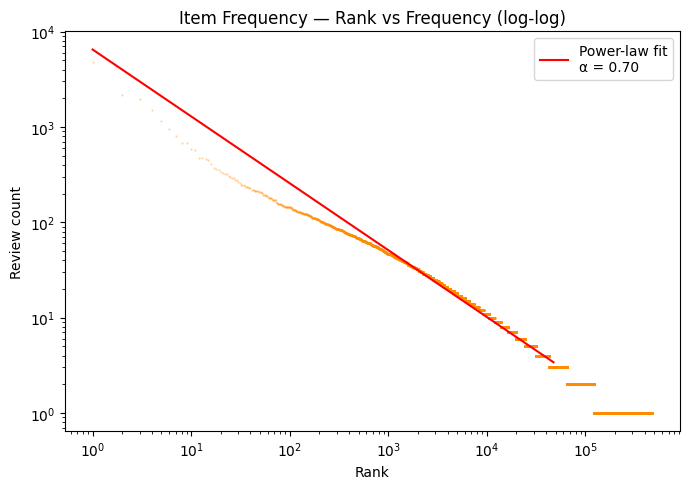


parent_asin Zipf alpha estimate: 0.7012


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ranks_item = np.arange(1, len(item_freq) + 1)
freqs_item = item_freq.values

ax.loglog(ranks_item, freqs_item, ".", markersize=1, alpha=0.4, color="darkorange")

top_n_item = max(100, len(ranks_item) // 10)
log_r2 = np.log(ranks_item[:top_n_item])
log_f2 = np.log(freqs_item[:top_n_item])
slope2, intercept2 = np.polyfit(log_r2, log_f2, 1)
fit2 = np.exp(intercept2) * ranks_item[:top_n_item] ** slope2
ax.loglog(ranks_item[:top_n_item], fit2, color="red", linewidth=1.5,
          label=f"Power-law fit\nα = {-slope2:.2f}")

ax.set_title("Item Frequency — Rank vs Frequency (log-log)")
ax.set_xlabel("Rank")
ax.set_ylabel("Review count")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "plots" / "01a_item_freq.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{ITEM_COL} Zipf alpha estimate: {-slope2:.4f}")

## Product Key Frequency — Zipf Behavior

Phân tích tần suất `parent_asin` cho thấy product key cũng có xu hướng **Zipf-like / power-law**, tương tự như `user_id`. Trên biểu đồ rank-frequency dạng log-log, tần suất review giảm dần theo rank và tạo thành xu hướng gần tuyến tính ở một phần lớn của phân phối. Điều này cho thấy chỉ có một nhóm nhỏ sản phẩm nhận được nhiều review, trong khi phần lớn sản phẩm chỉ xuất hiện rất ít lần.

Trong 1,000,000 review, có **476,112 unique items**, cao hơn nhiều so với **119,926 unique users**. Median số review trên mỗi item chỉ là **1**, nghĩa là phần lớn sản phẩm chỉ xuất hiện một lần trong sample. Tuy nhiên, p99 đạt **18 reviews/item**, và item phổ biến nhất có tới **4,772 reviews**. Điều này xác nhận rằng product key có cardinality rất cao nhưng vẫn tồn tại một nhóm nhỏ hot items.

Tham số Zipf ước lượng cho `parent_asin` là:

```text
alpha = 0.7012
```

Giá trị alpha này cao hơn so với user frequency, cho thấy item frequency giảm nhanh hơn theo rank. Khi sinh synthetic data, cần giữ lại cả high cardinality của product key và phân phối tần suất dạng long-tail, thay vì sinh item key theo uniform distribution

## 6. Cardinality Summary

**Câu hỏi:** Cardinality của từng cột là bao nhiêu?

Cardinality ảnh hưởng đến:
- GroupBy performance (số lượng group)
- Join cost (size của hash table)
- Memory footprint của string columns

In [15]:
cardinality_summary = []

for col in df.columns:
    n_unique = df[col].nunique()
    n_total  = len(df[col].dropna())
    uniqueness_ratio = n_unique / n_total if n_total > 0 else 0
    dtype    = str(df[col].dtype)
    
    cardinality_summary.append({
        "column"           : col,
        "dtype"            : dtype,
        "n_unique"         : n_unique,
        "n_total"          : n_total,
        "uniqueness_ratio" : round(uniqueness_ratio, 4),
    })

card_df = pd.DataFrame(cardinality_summary).sort_values("n_unique", ascending=False)
print("=== Cardinality Summary ===")
print(card_df.to_string(index=False))

=== Cardinality Summary ===
           column          dtype  n_unique  n_total  uniqueness_ratio
        review_id         object   1000000  1000000            1.0000
      review_text         object    927941  1000000            0.9279
       product_id         object    771319  1000000            0.7713
     review_title         object    537463  1000000            0.5375
      parent_asin         object    476112  1000000            0.4761
          user_id         object    119926  1000000            0.1199
      review_time datetime64[ns]      5450  1000000            0.0054
         text_len          int64      3161  1000000            0.0032
     helpful_vote          int32       393  1000000            0.0004
           rating           int8         5  1000000            0.0000
verified_purchase           bool         2  1000000            0.0000


## Cardinality Summary

Cardinality summary cho thấy các cột trong dataset có mức độ unique rất khác nhau, phản ánh rõ vai trò khác nhau của từng feature trong benchmark.

`review_id` có **1,000,000 unique values trên 1,000,000 dòng**, tức uniqueness ratio bằng **1.0**. Điều này xác nhận `review_id` là định danh duy nhất cho từng review và không phù hợp để dùng làm key cho groupby hoặc join vì gần như không có sự lặp lại.

Các cột text như `review_text` và `review_title` cũng có cardinality cao, lần lượt là **927,941** và **537,463** giá trị unique. Điều này cho thấy nội dung review khá đa dạng. Tuy nhiên, vì đây là text feature nên chúng phù hợp hơn cho phân tích độ dài, parsing cost hoặc synthetic text generation, thay vì làm key chính cho benchmark join/groupby.

Đối với product key, `product_id` có **771,319 unique values**, trong khi `parent_asin` có **476,112 unique values**. Điều này cho thấy `product_id` chi tiết hơn và gần với cấp variant/SKU, còn `parent_asin` gom nhiều variant về cùng product cha. Vì vậy, `parent_asin` là lựa chọn hợp lý hơn nếu mục tiêu benchmark là phân tích ở cấp product-level và giảm mức độ phân mảnh key.

`user_id` có **119,926 unique values**, tương ứng uniqueness ratio khoảng **0.1199**. Đây là mức cardinality trung bình so với các key khác và phù hợp để phân tích user frequency, skew, cũng như workload groupby/join theo user.

Các cột như `rating`, `verified_purchase`, `helpful_vote`, `review_time`, và `text_len` có cardinality thấp hơn nhiều. Trong đó, `rating` chỉ có **5 giá trị**, `verified_purchase` có **2 giá trị**, nên đây là các categorical feature thích hợp để lưu empirical distribution cho synthetic generator, không phải high-cardinality join key.

Nhìn chung, dataset có sự kết hợp giữa **high-cardinality identifiers**, **medium-cardinality entity keys**, và **low-cardinality categorical features**. Đặc điểm này quan trọng cho benchmark vì mỗi loại cột tạo ra áp lực khác nhau: high-cardinality key ảnh hưởng đến join/groupby cost, còn low-cardinality feature giúp kiểm tra aggregation theo nhóm nhỏ và tái tạo phân phối categorical trong synthetic data.

In [16]:
# Ước tính entropy của các cột phân loại (cardinality thấp)
from scipy.stats import entropy as scipy_entropy

LOW_CARD_THRESHOLD = 100  # cột có ít hơn 100 unique values

print("=== Entropy of Low-Cardinality Columns ===")
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= LOW_CARD_THRESHOLD:
        probs = df[col].value_counts(normalize=True).values
        H = scipy_entropy(probs, base=2)
        max_H = np.log2(n_unique) if n_unique > 1 else 1
        print(f"  {col:<20} | unique={n_unique:>4} | H={H:.3f} bits | max H={max_H:.3f} | normalized={H/max_H:.2%}")

=== Entropy of Low-Cardinality Columns ===
  rating               | unique=   5 | H=1.610 bits | max H=2.322 | normalized=69.34%
  verified_purchase    | unique=   2 | H=0.580 bits | max H=1.000 | normalized=57.99%


## Entropy of Low-Cardinality Columns

Entropy analysis cho thấy các cột categorical có cardinality thấp không phân bố đều, mà có mức độ mất cân bằng rõ rệt.

Với `rating`, entropy đạt **1.610 bits** trên mức tối đa lý thuyết **2.322 bits**, tương đương **69.34%** normalized entropy. Điều này cho thấy rating có mức độ đa dạng nhất định, nhưng phân phối không đều giữa 5 mức. Kết quả này phù hợp với rating distribution trước đó, trong đó rating **5 sao** chiếm tỷ lệ áp đảo.

Với `verified_purchase`, entropy đạt **0.580 bits** trên mức tối đa **1.000 bit**, tương đương **57.99%** normalized entropy. Điều này cho thấy biến boolean này cũng bị mất cân bằng, tức một trong hai trạng thái `True` hoặc `False` xuất hiện nhiều hơn đáng kể.

Nhìn chung, cả `rating` và `verified_purchase` đều không nên được sinh theo uniform distribution trong synthetic data. Thay vào đó, synthetic generator nên sử dụng **empirical probabilities** từ real data để giữ lại mức độ imbalance tự nhiên của các categorical features.

## 7. Memory Footprint Analysis

**Câu hỏi:** Với N rows thực tế, dataset chiếm bao nhiêu GB?

Thông số này giải thích tại sao cùng số rows nhưng real vs synthetic có kích thước khác nhau (xem BENCHMARK.md Section 1.1).

In [17]:
mem_per_col = df.memory_usage(deep=True)
total_mb    = mem_per_col.sum() / 1e6
n_rows      = len(df)
bytes_per_row = total_mb * 1e6 / n_rows

print("=== Memory Footprint ===")
print(f"  Rows             : {n_rows:,}")
print(f"  Total in-memory  : {total_mb:.1f} MB")
print(f"  Bytes per row    : {bytes_per_row:.1f} bytes")

print("\nMemory by column:")
for col, mem in mem_per_col.items():
    if col != "Index":
        print(f"  {col:<25} : {mem/1e6:.2f} MB")

# Projection cho các benchmark sizes
print("\n=== Projected Size for Benchmark Targets ===")
for target_rows in [1_000_000, 10_000_000, 50_000_000]:
    est_gb = bytes_per_row * target_rows / 1e9
    print(f"  {target_rows/1e6:.0f}M rows  →  ~{est_gb:.2f} GB")

=== Memory Footprint ===
  Rows             : 1,000,000
  Total in-memory  : 683.9 MB
  Bytes per row    : 683.9 bytes

Memory by column:
  review_id                 : 60.00 MB
  user_id                   : 77.00 MB
  product_id                : 59.00 MB
  parent_asin               : 59.00 MB
  rating                    : 1.00 MB
  review_title              : 72.12 MB
  review_text               : 334.76 MB
  review_time               : 8.00 MB
  helpful_vote              : 4.00 MB
  verified_purchase         : 1.00 MB
  text_len                  : 8.00 MB

=== Projected Size for Benchmark Targets ===
  1M rows  →  ~0.68 GB
  10M rows  →  ~6.84 GB
  50M rows  →  ~34.19 GB


## Memory Footprint

Memory footprint cho thấy tập dữ liệu 1M rows sử dụng khoảng **683.9 MB** trong bộ nhớ, tương đương trung bình **683.9 bytes/row**. Đây là mức sử dụng bộ nhớ khá lớn đối với một dataset review, chủ yếu do nhiều cột có kiểu `object`, đặc biệt là các cột text và string identifier.

Trong các cột, `review_text` chiếm nhiều bộ nhớ nhất với khoảng **334.76 MB**, gần một nửa tổng memory footprint. Điều này phù hợp với phân tích text length trước đó: mặc dù phần lớn review ngắn, vẫn tồn tại nhiều text value khác nhau và một số review rất dài, làm tăng chi phí lưu trữ và xử lý. Các cột string khác như `user_id`, `review_title`, `review_id`, `product_id`, và `parent_asin` cũng chiếm đáng kể bộ nhớ do được lưu dưới dạng object trong Pandas.

Ngược lại, các cột numeric và boolean như `rating`, `helpful_vote`, `verified_purchase`, `review_time`, và `text_len` có memory footprint nhỏ hơn nhiều. Ví dụ, `rating` và `verified_purchase` chỉ chiếm khoảng **1 MB** mỗi cột, cho thấy việc dùng dtype tối ưu như `int8`, `int32`, `bool`, và `datetime64` giúp giảm đáng kể chi phí bộ nhớ.

Khi scale lên các benchmark target, kích thước in-memory được ước lượng khoảng **6.84 GB cho 10M rows** và **34.19 GB cho 50M rows**. Điều này cho thấy các workload ở quy mô lớn sẽ tạo áp lực đáng kể lên memory, đặc biệt với Pandas hoặc các framework eager execution. Vì vậy, benchmark ở các scale lớn cần đặc biệt chú ý đến memory usage, out-of-core capability, và chi phí xử lý các cột text/object.

## 8. Summary — Parameters for Synthetic Generator

Tóm tắt tất cả thông số cần thiết cho notebook `01b_calibrate_synthetic.ipynb`

In [18]:
# ── Tổng hợp tất cả parameters cần thiết ──

log_text_len = np.log(text_len[text_len > 0])
mu_log, sigma_log = log_text_len.mean(), log_text_len.std()

summary = {
    "text_length": {
        "distribution" : "log-normal",
        "mu"           : round(mu_log, 4),
        "sigma"        : round(sigma_log, 4),
        "p50"          : int(text_len.quantile(0.50)),
        "p90"          : int(text_len.quantile(0.90)),
        "p99"          : int(text_len.quantile(0.99)),
    },
    "user_id": {
        "distribution"   : "zipf",
        "n_unique"       : len(user_freq),
        "zipf_alpha"     : round(-slope, 4),
        "single_review_pct": round(single_review_pct, 4),
    },
    ITEM_COL: {
        "distribution"   : "zipf",
        "n_unique"       : len(item_freq),
        "zipf_alpha"     : round(-slope2, 4),
    },
    "rating": {
        "distribution" : "categorical (empirical)",
        "probs"        : dict(rating_probs.round(4)),
    },
    "memory": {
        "bytes_per_row" : round(bytes_per_row, 1),
        "sample_rows"   : n_rows,
        "sample_mb"     : round(total_mb, 1),
    }
}

import json
print("=== SYNTHETIC GENERATOR PARAMETERS ===")
print(json.dumps(summary, indent=2, default=str))

# Lưu ra file để 01b có thể load lại
params_path = PROJECT_ROOT / "configs" / "real_data_params.json"
params_path.parent.mkdir(parents=True, exist_ok=True)
with open(params_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"\nSaved to: {params_path}")

=== SYNTHETIC GENERATOR PARAMETERS ===
{
  "text_length": {
    "distribution": "log-normal",
    "mu": 4.7013,
    "sigma": 1.1979,
    "p50": 122,
    "p90": 472,
    "p99": 1234
  },
  "user_id": {
    "distribution": "zipf",
    "n_unique": 119926,
    "zipf_alpha": 0.55,
    "single_review_pct": 0.2183
  },
  "parent_asin": {
    "distribution": "zipf",
    "n_unique": 476112,
    "zipf_alpha": 0.7012
  },
  "rating": {
    "distribution": "categorical (empirical)",
    "probs": {
      "1": 0.0579,
      "2": 0.0504,
      "3": 0.0909,
      "4": 0.1629,
      "5": 0.6379
    }
  },
  "memory": {
    "bytes_per_row": 683.9,
    "sample_rows": 1000000,
    "sample_mb": 683.9
  }
}

Saved to: ..\..\configs\real_data_params.json


## Synthetic Generator Parameters

Từ các phân tích trên real dataset 1M rows, các tham số chính cho synthetic generator đã được trích xuất và lưu lại vào file cấu hình `real_data_params.json`.

Đối với `review_text`, độ dài text được mô hình hóa bằng **log-normal distribution** với `mu = 4.7013` và `sigma = 1.1979`. Lựa chọn này phù hợp vì phân phối độ dài review trong real data bị lệch phải mạnh, với median **122 ký tự**, p90 **472 ký tự**, và p99 **1,234 ký tự**.

Đối với `user_id`, tần suất user được mô hình hóa bằng **Zipf distribution** với **119,926 unique users** và `zipf_alpha = 0.55`. Ngoài ra, tỷ lệ user chỉ xuất hiện một lần là khoảng **21.83%**, phản ánh rõ đặc điểm long-tail trong hành vi review của người dùng.

Đối với `parent_asin`, product key cũng được mô hình hóa bằng **Zipf distribution**, với **476,112 unique items** và `zipf_alpha = 0.7012`. Giá trị alpha cao hơn so với user cho thấy tần suất product giảm nhanh hơn theo rank, trong khi vẫn tồn tại một nhóm nhỏ sản phẩm rất phổ biến.

Đối với `rating`, synthetic generator sử dụng **empirical categorical distribution** thay vì uniform distribution. Điều này giúp giữ lại sự mất cân bằng tự nhiên của dữ liệu thật, trong đó rating **5 sao** chiếm tỷ lệ cao nhất.

Cuối cùng, memory footprint được ghi nhận ở mức khoảng **683.9 bytes/row**, tương đương **683.9 MB** cho 1M rows. Thông tin này có thể được dùng để ước lượng memory requirement khi sinh dữ liệu ở các quy mô lớn hơn như 10M hoặc 50M rows.

Các tham số này sẽ được sử dụng làm cấu hình cố định cho bước synthetic data generation, nhằm đảm bảo dữ liệu synthetic giữ lại các đặc điểm quan trọng của real data: **text length long-tail**, **user/item skew**, **rating imbalance**, và **memory scale tương đối thực tế**.

## 9. Key Insights

Tóm tắt kết quả phân tích để truyền sang `01b_calibrate_synthetic.ipynb`:

| Feature      | Observation | Implication for Synthetic |
|--------------|-------------|---------------------------|
| `text_len`   | Log-normal distribution | Dùng `np.random.lognormal(mu, sigma)` |
| `user_id`    | Zipf power-law | Dùng `np.random.zipf(alpha)` |
| `product_id` | Zipf power-law | Tương tự user_id nhưng cardinality thấp hơn |
| `rating`     | Skewed về 5 | Dùng empirical distribution |
| Memory       | ~X bytes/row | Scale theo đúng con số này khi plan benchmark |

**Nguyên tắc quan trọng:** Tất cả parameters trên phải được **freeze** sau khi calibrate. Không được tái calibrate theo từng dataset size (xem BENCHMARK.md Section 4.1).